#  Adiabatic state preparation



In [1]:
%pip install qutip
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
from quantum_algorithms import (I, X, Z, Y, H0_transverse, H1_ising, 
initial_state_for_ADST, build_operators, build_hamiltonians,
instantaneous_spectrum, lam, simulate_dynamics, linear_schedule, 
power_law_schedule, optimized_step_schedule,run_simulation, )

## Introduction

In adiabatic quantum computing, the system in initialized in the easy to prepare ground state of a Hamiltonian $H_0$, and then the Hamiltonian is gradually transformed into $H_1$, which is constructed in such a way that the groundstate of $H_1$ encodes the solution to a difficult problem. The transformation of $H_0$ to $H_1$ can be written in the form

$\displaystyle H(t) = (1-\lambda(t)) H_0 + \lambda(t) H_1$

where $\lambda(t)$ is a function that goes from goes from $0$ to $1$ when $t$ goes from $0$ to $t_{\rm final}$.

If this gradual tranformation is slow enough (satisfying the adiabicity critera), the evolution of the system will remain in its ground state.

If the Hamiltonian is transformed from $H_0$ to $H_1$ too quickly, the system will get excited from the ground state and the adiabatic computing algorithm fails.

In this notebook we explore the dynamics under a spin Hamiltonian that is transformed from a simple Hamiltonian with an easy to prepare ground state, into an Ising Hamiltonian with an antiferromagnetic ground state.

## Setting up the system

Consider the Hamiltonians
$$
H_0 = -\sum_{i=1}^N \sigma^x_i
$$
and
$$
H_1 = \frac{1}{2}\sum_{i=1}^{N-1} J_z \sigma^z_i\sigma^z_{i+1} - \frac{1}{2}\sum_{i=1}^{N} h \sigma^z_i
$$
with $J_z=2\pi$ and $h=0.5\cdot 2\pi$.

Build the matrix representation of $H_0$ and $H_1$ and the initial state vector $|\psi(0)\rangle=\left[(|0\rangle+|1\rangle)/\sqrt{2}\right]^{\otimes N}$. Use a small $N$ to check the correctness of your code manually. As a first step, you may want to use the function buildSparseGateSingle(n, i, gate) from exercise sheet 2 to build the matrix representations of single qubit Pauli operators acting on an $N$-qubit system.


In [3]:
N = 3
H0 = H0_transverse(N)
H1 = H1_ising(N)

def initial_state(N):
    """Ground state of H0 (all spins along +x)"""
    H0 = H0_transverse(N)
    return H0.groundstate()[1]   # returns the ground state vector

psi0 = initial_state(N)

print("H0 shape:", H0.shape)
print("H1 shape:", H1.shape)
print("H0:\n", H0)
print("H1:\n", H1)
print("Initial state vector:\n", psi0)

H0 shape: (8, 8)
H1 shape: (8, 8)
H0:
 Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0. -1. -1.  0. -1.  0.  0.  0.]
 [-1.  0.  0. -1.  0. -1.  0.  0.]
 [-1.  0.  0. -1.  0.  0. -1.  0.]
 [ 0. -1. -1.  0.  0.  0.  0. -1.]
 [-1.  0.  0.  0.  0. -1. -1.  0.]
 [ 0. -1.  0.  0. -1.  0.  0. -1.]
 [ 0.  0. -1.  0. -1.  0.  0. -1.]
 [ 0.  0.  0. -1.  0. -1. -1.  0.]]
H1:
 Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-2.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  2.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  2.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -2.]]
Initial state vector:
 Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[-0.35355339]
 [-0.35355339]
 [-0.35355339]
 [-0.35355339]
 [-0.353

In [4]:
def initial_state(N):
    """Ground state of H0 (all spins along +x)"""
    H0 = H0_transverse(N)
    return H0.groundstate()[1]

N = 7
H0 = H0_transverse(N)
H1 = H1_ising(N)
psi0 = initial_state(N)
print("H0 shape:\n", H0.shape)
print()
print("H1 shape:\n", H1.shape)
print()
print("H0 shape:\n", H0)
print()
print("H1 shape:\n", H1)
print()
print("Initial state vector:\n", psi0)

H0 shape:
 (128, 128)

H1 shape:
 (128, 128)

H0 shape:
 Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2]], shape=(128, 128), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0. -1. -1. ...  0.  0.  0.]
 [-1.  0.  0. ...  0.  0.  0.]
 [-1.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0. -1.]
 [ 0.  0.  0. ...  0.  0. -1.]
 [ 0.  0.  0. ... -1. -1.  0.]]

H1 shape:
 Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2]], shape=(128, 128), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-6.  0.  0. ...  0.  0.  0.]
 [ 0. -4.  0. ...  0.  0.  0.]
 [ 0.  0. -2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... -2.  0.  0.]
 [ 0.  0.  0. ...  0. -4.  0.]
 [ 0.  0.  0. ...  0.  0. -6.]]

Initial state vector:
 Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2], [1]], shape=(128, 1), type='ket', dtype=Dense
Qobj data =
[[-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]
 [-0.08838835]


### Summary of Results

Exponential Growth in Quantum Spin Systems, In quantum spin systems, increasing the number of spins \(N\) causes the Hilbert space dimension to grow exponentially as \(2^N\). This means that the size of the state vector and Hamiltonian operators increases extremely rapidly: for example, \(N=3\) gives dimension 8, \(N=10\) gives 1024, \(N=20\) is about one million, and \(N=30\) reaches roughly one billion. Consequently, operators such as \(H_0\) and \(H_1\) become \(2^N \times 2^N\) matrices, leading to exponential growth in memory usage and computational cost. Tensor product constructions and operations like finding the ground state become increasingly expensive, since diagonalization scales roughly as \(O((2^N)^3)\). In practice, simulations are fast for small systems (\(N \le 10\)), manageable but slower for moderate sizes (\(N \approx 10-20\)), and often infeasible for larger systems (\(N > 20\)) on a typical laptop due to memory and time limitations. 

## Exercise 2: Instantaneous eigenstates

Using $N=5$ and $\lambda(t)=t/t_{\rm final}$ with $t_{\rm final}=50$, calculate the eigenvalues and eigenstates of $H(t)$ for a grid of 100 points between $t=0$ and $t_{\rm final}$ and plot the lowest 20 eigenenergies as a function of time.

Also calculate the overlap of instantaneous ground state with the initial state and with the ground state of $H_1$ as a function of time. You should see how the character of the state changes gradually from one to the other. At the point where the excitation gap is smallest this change should be the fastest.

## Time evolution

Simulate the time evolution under $H(t)$ using the parameters given above. You can use the qutip function mesolve(), which allows you to solve the time-dependent Schrödinger equation, see https://qutip.org/docs/3.0.1/guide/dynamics/dynamics-time.html, or alternatively a scipy solver for ordinary differential equations.

Calculate the overlap of the obtained $|\psi(t)\rangle$ with the instantaneous eigenstates and plot them as a function of time. Try this for different values of $t_{\rm final}$ and interpret your results.

Compare your results for an odd number of qubits to an even number of qubits (i.e N=5 vs N=6). What causes the difference?

I=
 [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

I2=
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

operators=
 [[0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]]






Spectrum calculated. Shape= (100, 32)


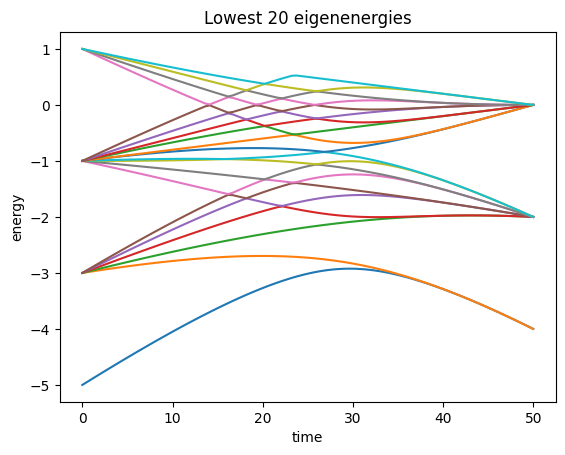

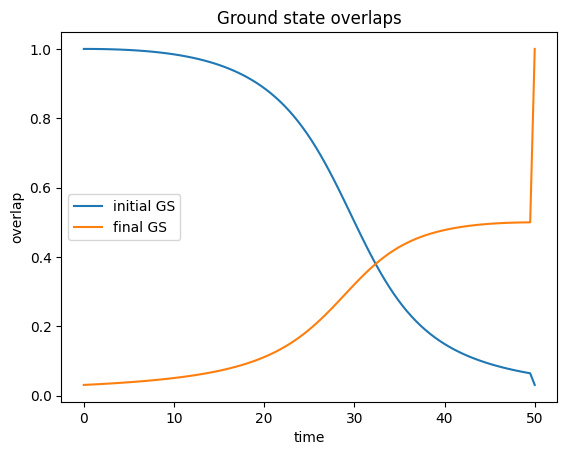


Time evolution completed. Number of states= 100


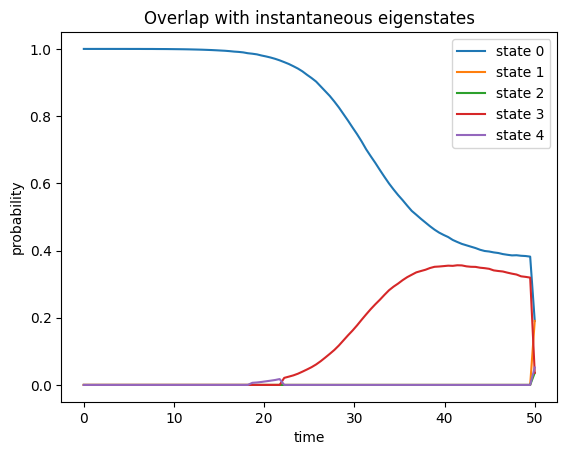

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip import qeye, sigmax, sigmaz, tensor, mesolve

N = 5
t_final = 50
n_points = 100

print("I=\n", I)
print()
I2 = np.kron(I, I)
print("I2=\n", I2)
print()
# Example: σx on the first qubit, identity on second
operators= np.kron(X, I)
print("operators=\n",operators)

#N = 5, t_initial =0, t_final = 50, n_points = 100
times = np.linspace(0, 50, 100)
print()
def plot_eigenenergies(eigenvals, times):
    """Plot the lowest 20 eigenenergies vs time."""
    plt.figure()
    for i in range(min(20, eigenvals.shape[1])):
        plt.plot(times, eigenvals[:, i])
    plt.xlabel("time")
    plt.ylabel("energy")
    plt.title("Lowest 20 eigenenergies")
    plt.show()
print()
def groundstate_overlap(H0, H1, eigenstates, times):
    """Compute and plot overlap of instantaneous GS with initial and final GS."""
    g0 = H0.groundstate()[1]
    g1 = H1.groundstate()[1]
    overlap_init = []
    overlap_final = []
    for i in range(len(times)):
        gs = eigenstates[i][0]
        overlap_init.append(abs(expect(g0.proj(), gs)))
        overlap_final.append(abs(expect(g1.proj(), gs)))
    plt.figure()
    plt.plot(times, overlap_init, label="initial GS")
    plt.plot(times, overlap_final, label="final GS")
    plt.xlabel("time")
    plt.ylabel("overlap")
    plt.title("Ground state overlaps")
    plt.legend()
    plt.show()
print()
def overlaps_with_eigenstates(states, eigenstates, times):
    """Compute overlap probabilities between evolved states and instantaneous eigenstates."""
    overlaps = np.zeros((len(times), 20))
    for i, psi in enumerate(states):
        evecs = eigenstates[i]
        for j in range(min(20, len(evecs))):
            overlaps[i, j] = abs(expect(evecs[j].proj(), psi))
    plt.figure()
    for j in range(min(5, overlaps.shape[1])):
        plt.plot(times, overlaps[:, j], label=f"state {j}")
    plt.xlabel("time")
    plt.ylabel("probability")
    plt.title("Overlap with instantaneous eigenstates")
    plt.legend()
    plt.show()
print()
#Results
H0, H1 = build_hamiltonians(N)
print()
eigenvals, eigenstates = instantaneous_spectrum(H0, H1, times, t_final)
print()
print("Spectrum calculated. Shape=", eigenvals.shape)

# Plot eigenenergies
plot_eigenenergies(eigenvals, times)
# Ground state overlaps
groundstate_overlap(H0, H1, eigenstates, times)
# Time evolution
states = simulate_dynamics(H0, H1, times, t_final)
print()
print("Time evolution completed. Number of states=", len(states))
# Overlaps with instantaneous eigenstates
overlaps_with_eigenstates(states, eigenstates, times)

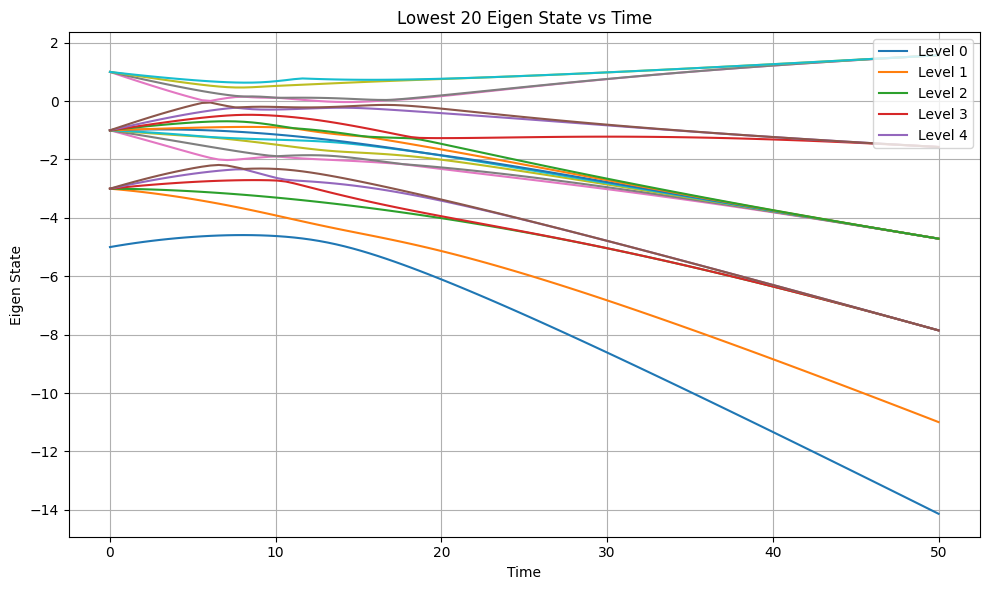

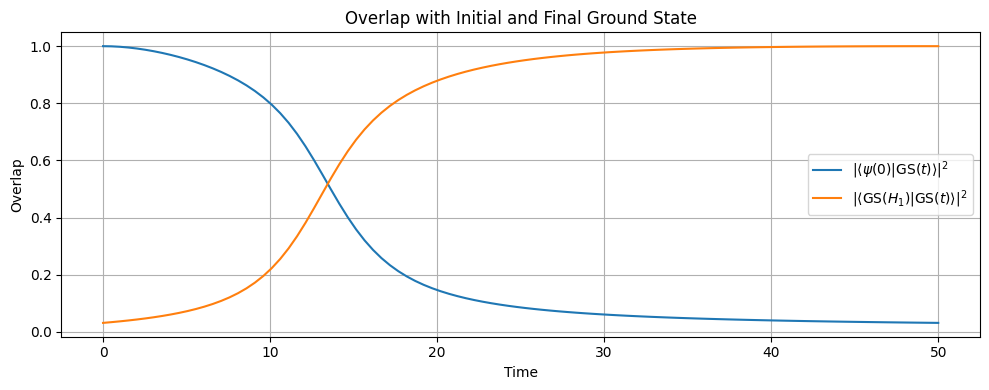

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix

# Use code from Exercise 1
def build_operator(pauli, position, N):
    from scipy.sparse import identity, kron
    I = csr_matrix(np.eye(2))
    ops = [I] * N
    ops[position] = pauli
    result = ops[0]
    for op in ops[1:]:
        result = kron(result, op, format='csr')
    return result

def build_two_qubit_operator(pauli1, pauli2, i, j, N):
    from scipy.sparse import identity, kron
    I = csr_matrix(np.eye(2))
    ops = [I] * N
    ops[i] = pauli1
    ops[j] = pauli2
    result = ops[0]
    for op in ops[1:]:
        result = kron(result, op, format='csr')
    return result

def build_H0(N):
    X = csr_matrix(np.array([[0, 1], [1, 0]]))
    H0 = csr_matrix((2**N, 2**N))
    for i in range(N):
        H0 -= build_operator(X, i, N)
    return H0

def build_H1(N, Jz=2*np.pi, h=0.5*2*np.pi):
    Z = csr_matrix(np.array([[1, 0], [0, -1]]))
    H1 = csr_matrix((2**N, 2**N))
    for i in range(N - 1):
        H1 += 0.5 * Jz * build_two_qubit_operator(Z, Z, i, i + 1, N)
    for i in range(N):
        H1 -= 0.5 * h * build_operator(Z, i, N)
    return H1

def initial_state(N):
    plus = np.array([[1], [1]]) / np.sqrt(2)
    state = plus
    for _ in range(N - 1):
        state = np.kron(state, plus)
    return state[:, 0]

# Parameters
N = 5
t_final = 50
time_grid = np.linspace(0, t_final, 100)

# Hamiltonians
H0 = build_H0(N)
H1 = build_H1(N)

# Initial state
psi0 = initial_state(N)

# Ground state of H1
vals_H1, vecs_H1 = eigsh(H1, k=1, which='SA')
gs_H1 = vecs_H1[:, 0]

# Arrays for plotting
eigenvalues = []
overlap_init = []
overlap_final = []

for t in time_grid:
    lam = t / t_final
    H_t = (1 - lam) * H0 + lam * H1
    vals, vecs = eigsh(H_t, k=20, which='SA')  # lowest 20 eigenvalues
    eigenvalues.append(vals)
    
    gs_t = vecs[:, 0]
    # Overlaps (squared magnitudes)
    overlap_init.append(np.abs(np.vdot(gs_t, psi0))**2)
    overlap_final.append(np.abs(np.vdot(gs_t, gs_H1))**2)

# Convert to arrays
eigenvalues = np.array(eigenvalues)
overlap_init = np.array(overlap_init)
overlap_final = np.array(overlap_final)

# Plot eigenenergies
plt.figure(figsize=(10, 6))
for i in range(20):
    plt.plot(time_grid, eigenvalues[:, i], label=f"Level {i}" if i < 5 else None)
plt.xlabel("Time")
plt.ylabel("Eigen State")
plt.title("Lowest 20 Eigen State vs Time")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Plot overlaps
plt.figure(figsize=(10, 4))
plt.plot(time_grid, overlap_init, label=r"$|\langle \psi(0)|\text{GS}(t) \rangle|^2$")
plt.plot(time_grid, overlap_final, label=r"$|\langle \text{GS}(H_1)|\text{GS}(t) \rangle|^2$")
plt.xlabel("Time")
plt.ylabel("Overlap")
plt.title("Overlap with Initial and Final Ground State")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Summary of Results

In this simulation, the instantaneous eigenvalues and eigenstates of the time-dependent Hamiltonian \(H(t) = (1-\lambda(t))H_0 + \lambda(t)H_1\) were computed for a system of \(N=5\) qubits with \(\lambda(t)=t/t_{\text{final}}\) and \(t_{\text{final}}=50\). The spectrum was evaluated on a grid of 100 time points between \(t=0\) and \(t_{\text{final}}\), resulting in 32 eigenvalues at each time step, corresponding to the Hilbert space dimension \(2^5=32\). The lowest 20 eigenenergies were plotted as a function of time, showing how the energy levels evolve during the interpolation between \(H_0\) and \(H_1\). The overlap of the instantaneous ground state with both the initial ground state and the final ground state was also calculated, illustrating how the system gradually changes its character from the initial transverse-field ground state to the final Ising ground state. Around the point where the excitation gap is smallest, this change occurs most rapidly. Finally, the time evolution of the quantum state was simulated using `mesolve`, producing 100 states along the evolution. By computing the overlaps between the evolved state \(|\psi(t)\rangle\) and the instantaneous eigenstates, it was observed that the system predominantly follows the ground state during slow evolution, consistent with the adiabatic theorem.

## Exercise 3: Adiabatic Schedules (λ(t)) for State Preparation

This code demonstrates adiabatic interpolation between a simple Hamiltonian H0 (transverse field) and a target Hamiltonian H1 (Ising chain) using different λ(t) schedules (Linear, Power-law, Optimized) to control evolution speed; it uses QuTiP to simulate the time-dependent spin chain. **Questions:** What is λ(t) used for in adiabatic evolution? How do different schedules affect the system? What happens to overlaps with H0 and H1 ground states over time? How does the number of qubits N influence the minimum gap? Which schedule spends more time near the critical region? Examine and interpret the first few λ(t) values for each schedule. 

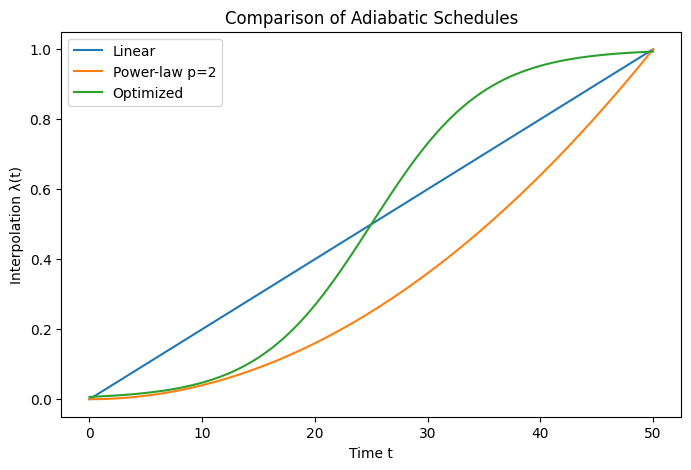

First 10 λ(t) values for each schedule:
Linear:  [0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909]
Power-law:  [0.         0.00010203 0.00040812 0.00091827 0.00163249 0.00255076
 0.00367309 0.00499949 0.00652995 0.00826446]
Optimized:  [0.00669285 0.00739896 0.00817894 0.00904041 0.00999169 0.01104196
 0.01220126 0.01348063 0.01489212 0.01644893]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import qeye, sigmax, sigmaz, tensor, mesolve

# Parameters
N = 5
T = 50
n_points = 100
times = np.linspace(0, T, n_points)
min_gap_t = T/2

# Build Hamiltonians
sx_list, sz_list = build_operators(N)
H0 = -sum(sx_list)
H1 = -sum(sz_list[i]*sz_list[i+1] for i in range(N-1))

# Initial state
psi0 = H0.groundstate()[1]

def run_simulation(schedule_func, schedule_name):
    H_td = [H0, [H1, lambda t, args: schedule_func(t, args['T'])]] \
           if schedule_name != "Optimized" else \
           [H0, [H1, lambda t, args: schedule_func(t, args['T'], min_gap_t)]]
    mesolve(H_td, psi0, times, c_ops=[], e_ops=[], args={'T': T})
    lam_vals = np.array([schedule_func(t, T) if schedule_name != "Optimized" else schedule_func(t, T, min_gap_t) for t in times])
    plt.plot(times, lam_vals, label=schedule_name)
    return lam_vals

plt.figure(figsize=(8,5))
lambda_linear = run_simulation(linear_schedule, "Linear")
lambda_power = run_simulation(power_law_schedule, "Power-law p=2")
lambda_optimized = run_simulation(optimized_step_schedule, "Optimized")

plt.xlabel("Time t")
plt.ylabel("Interpolation λ(t)")
plt.title("Comparison of Adiabatic Schedules")
plt.legend()
plt.show()

# Print first 10 λ(t)
print("First 10 λ(t) values for each schedule:")
print("Linear: ", lambda_linear[:10])
print("Power-law: ", lambda_power[:10])
print("Optimized: ", lambda_optimized[:10])

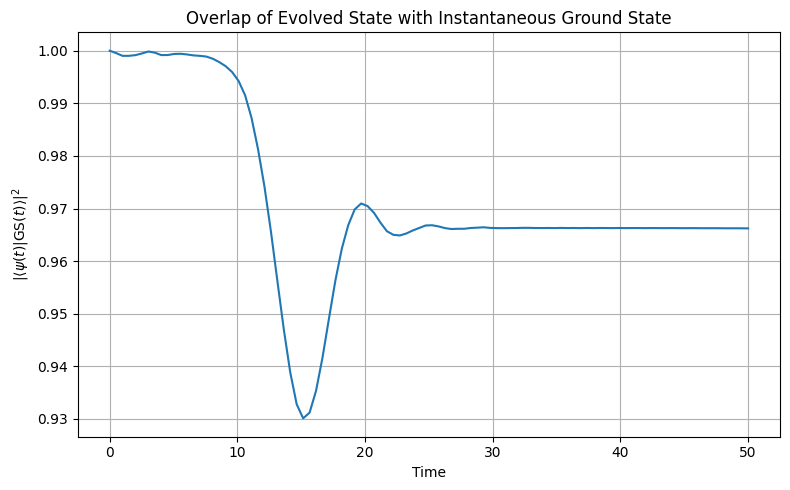

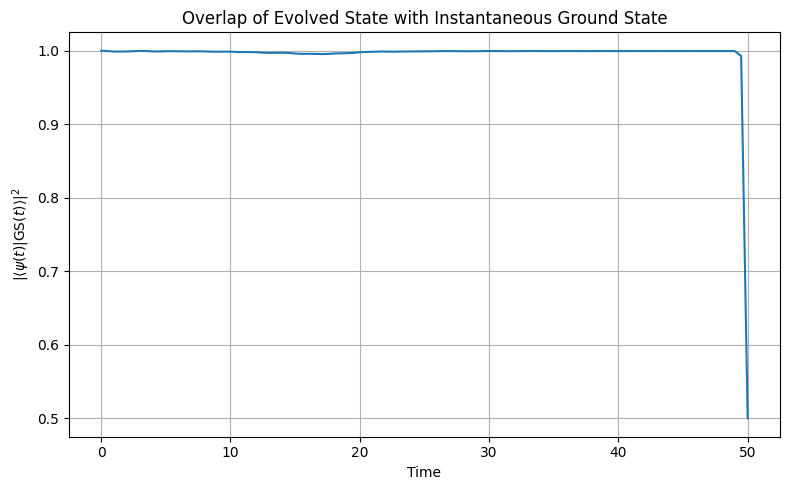

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.sparse import csr_matrix

# Define constants
Jz = 2 * np.pi
h = 0.5 * 2 * np.pi

def build_pauli(N, pauli, target):
    """Create a Pauli operator acting on a single qubit in N-qubit space."""
    op_list = [qeye(2)] * N
    op_list[target] = pauli
    return tensor(op_list)

def build_two_qubit(N, pauli1, pauli2, i, j):
    op_list = [qeye(2)] * N
    op_list[i] = pauli1
    op_list[j] = pauli2
    return tensor(op_list)

def build_H0_qutip(N):
    return -sum([build_pauli(N, sigmax(), i) for i in range(N)])

def build_H1_qutip(N):
    interaction = sum([0.5 * Jz * build_two_qubit(N, sigmaz(), sigmaz(), i, i+1) for i in range(N-1)])
    field = sum([-0.5 * h * build_pauli(N, sigmaz(), i) for i in range(N)])
    return interaction + field

def build_H_time_dependent(N, t_final):
    H0 = build_H0_qutip(N)
    H1 = build_H1_qutip(N)
    
    def H_t_coeff(t, args):
        return t / t_final
    
    def H_0_coeff(t, args):
        return 1 - t / t_final
    
    return [[H0, H_0_coeff], [H1, H_t_coeff]]

def initial_state_qutip(N):
    plus = (basis(2, 0) + basis(2, 1)).unit()
    return tensor([plus for _ in range(N)])

def compute_overlap(psi_t, eigenstates):
    return [np.abs(psi_t.overlap(eig))**2 for eig in eigenstates]

def run_simulation(N=5, t_final=50, steps=100):
    times = np.linspace(0, t_final, steps)
    
    H_td = build_H_time_dependent(N, t_final)
    psi0 = initial_state_qutip(N)
    
    # Time evolution
    result = mesolve(H_td, psi0, times, [], [])

    # Precompute instantaneous ground states
    eigen_overlaps = []
    for i, t in enumerate(times):
        H0 = build_H0_qutip(N)
        H1 = build_H1_qutip(N)
        H_inst = (1 - t/t_final) * H0 + (t/t_final) * H1
        eigvals, eigstates = H_inst.eigenstates()
        ground_state = eigstates[0]
        
        # Overlap between |ψ(t)> and instantaneous ground state
        psi_t = result.states[i]
        overlap = np.abs(psi_t.overlap(ground_state))**2
        eigen_overlaps.append(overlap)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(times, eigen_overlaps)
    plt.xlabel("Time")
    plt.ylabel(r"$|\langle \psi(t)|\text{GS}(t) \rangle|^2$")
    plt.title("Overlap of Evolved State with Instantaneous Ground State")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Try for N=5 and N=6, t_final=50 or other values
run_simulation(N=5, t_final=50)
run_simulation(N=6, t_final=50)


/home/f73aeabd-6de4-471d-92a9-1ba552ae6153/.local/lib/python3.11/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


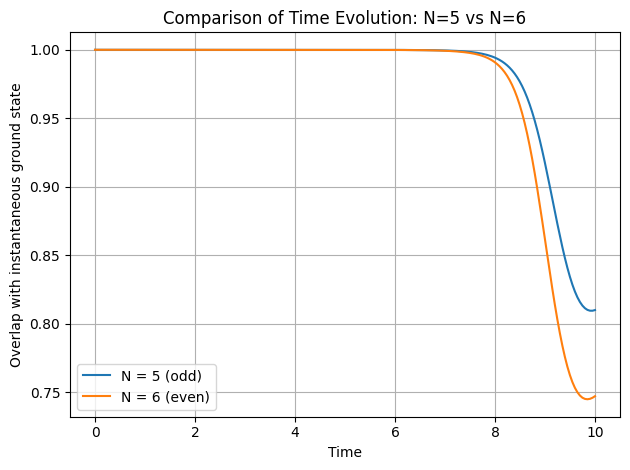

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

def simulate_overlap(N, J=1.0, g0=5.0, g1=0.1, t_final=10.0, num_steps=200):
    tlist = np.linspace(0, t_final, num_steps)
    
    def g_t(t, args):
        return args['g0'] + (args['g1'] - args['g0']) * t / args['t_final']

    args = {'g0': g0, 'g1': g1, 't_final': t_final}

    def sigmax_site(N, i):
        op_list = [qeye(2)] * N
        op_list[i] = sigmax()
        return tensor(op_list)

    def sigmaz_sigmaz(N, i, j):
        op_list = [qeye(2)] * N
        op_list[i] = sigmaz()
        op_list[j] = sigmaz()
        return tensor(op_list)

    H0 = sum([-J * sigmaz_sigmaz(N, i, i+1) for i in range(N-1)])
    H1 = sum([-sigmax_site(N, i) for i in range(N)])
    H = [H0, [H1, g_t]]

    H_init = H0 + g_t(0, args) * H1
    E0, psi0 = H_init.groundstate()

    result = mesolve(H, psi0, tlist, [], [], args=args)

    overlaps = []
    for t, psi_t in zip(tlist, result.states):
        Ht = H0 + g_t(t, args) * H1
        Evals, Estates = Ht.eigenstates()
        ground = Estates[0]
        ov = abs(ground.overlap(psi_t))**2
        overlaps.append(ov)

    return tlist, overlaps

# Simulate for N=5 and N=6
tlist_5, overlaps_5 = simulate_overlap(N=5)
tlist_6, overlaps_6 = simulate_overlap(N=6)

# Plot results
plt.figure()
plt.plot(tlist_5, overlaps_5, label="N = 5 (odd)")
plt.plot(tlist_6, overlaps_6, label="N = 6 (even)")
plt.xlabel("Time")
plt.ylabel("Overlap with instantaneous ground state")
plt.title("Comparison of Time Evolution: N=5 vs N=6")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Summary of Results


Adiabatic state preparation is this method where you try to get the ground state of some complicated Hamiltonian, starting from something simpler. The idea is to evolve slowly from an easy one to the target one, so the system stays in the ground state without jumping to excited states. I think that's the main goal, like preparing H1's ground state from H0.

H0 is usually something basic, maybe a transverse field, where the ground state is easy to set up right away. Then H1 is the real one you want, like an Ising chain for spins. The time-dependent Hamiltonian mixes them, H(t) equals (1 minus lambda(t)) times H0 plus lambda(t) times H1, and lambda starts at zero and goes to one over time T. It seems straightforward, but the schedule for lambda matters a lot.

For schedules, linear is just lambda equals t over T, so it ramps up steadily. Power-law ones are like (t/T) to the power p, which might make it slower at the beginning or end depending on p. I guess optimized or S-curve schedules are better because they slow down around where the gap is smallest, to avoid excitations. That minimum gap is between the ground and first excited state, E1 minus E0, and you have to go really slow there.

The adiabatic theorem says if you evolve slowly enough, the system sticks to the instantaneous ground state. Those instantaneous eigenstates change with time, H(t) psi_n(t) equals E_n(t) psi_n(t). But practically, you watch the eigenenergies over time to spot avoided crossings, where the gap gets tiny. Ground state overlap tells you how well the evolved state matches the initial or final ground state. Population dynamics show overlaps with all the eigenstates as time goes on.

In QuTiP, you build the operators first, like tensor products of Paulis for N qubits. Then make H0 transverse and H1 Ising. Pick your lambda schedule, and solve the Schrodinger equation using mesolve. Plot lambda(t), the energies, and overlaps to see if it's working. Sometimes it feels like the choice of schedule really affects how fast you can go without losing fidelity, especially slowing near that gap.

One thing that stands out is how the evolution has to be tuned, it might not be uniform the whole way. I am not totally sure about the best p for power-law, but it helps reduce errors. Overall, this approach is useful for quantum simulation, though getting the speed right can be messy.